<a href="https://colab.research.google.com/github/kenta-afk/cnn-lstm-model-for-valorant/blob/main/model-v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!unzip -q /content/cnn-lstm-project-images.zip -d /content/


In [4]:
import os

# List the contents of the unzipped directory
print(os.listdir('/content/cnn-lstm-project-images/'))

['sequence3', '.git', 'README.md', 'sequence4', 'sequence2', 'sequence1']


In [5]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping # Add this import
import numpy as np
import os
import cv2 # For image processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Define image parameters
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32
SEQUENCE_LENGTH = 8 # Number of frames per sequence for LSTM

print("Libraries imported and parameters defined.")

Libraries imported and parameters defined.


In [6]:
def load_and_preprocess_data(base_path, img_height, img_width, sequence_length):
    all_sequences = []
    all_labels = []
    label_names = []

    # Iterate through each sequence directory (e.g., sequence1, sequence2)
    for sequence_dir_name in sorted(os.listdir(base_path)):
        sequence_path = os.path.join(base_path, sequence_dir_name)
        # Skip non-directories, .git, and __MACOSX directories
        if not os.path.isdir(sequence_path) or sequence_dir_name in ['.git', '__MACOSX']:
            continue

        # Iterate through each action directory (e.g., 1.Mid defalt, 2.Brush)
        for action_dir_name in sorted(os.listdir(sequence_path)):
            action_path = os.path.join(sequence_path, action_dir_name)
            if not os.path.isdir(action_path):
                # Skip files within sequence directories (e.g., .DS_Store or images directly inside sequence folders)
                continue

            # Extract label, handling both 'Number.ActionName' and 'ActionName' formats
            parts = action_dir_name.split('.', 1)
            if len(parts) >= 2:
                label = parts[1].strip() # Use part after the first dot
            else:
                label = action_dir_name.strip() # Use the full directory name as label

            # Ensure label is not empty after stripping
            if not label:
                print(f"Warning: Skipping directory with empty label after processing: {action_dir_name} in {sequence_path}")
                continue

            if label not in label_names:
                label_names.append(label)

            images = []
            # Load all image paths in the current action directory
            for img_name in sorted(os.listdir(action_path)):
                # Ensure we handle both .jpg and .png files
                if img_name.endswith('.jpg') or img_name.endswith('.png'):
                    img_path = os.path.join(action_path, img_name)
                    images.append(img_path)

            # Create sequences of images and assign the label
            for i in range(0, len(images) - sequence_length + 1):
                sequence = images[i : i + sequence_length]
                all_sequences.append(sequence)
                all_labels.append(label)

    # Encode labels to integers
    label_encoder = LabelEncoder()
    # Check if there are any labels to encode before calling fit_transform
    if not all_labels:
        print("Error: No labels found after processing directories. Check data structure.")
        return np.array([]), np.array([]), 0, np.array([]), np.array([]), np.array([]), np.array([]), np.array([]) # Return empty arrays if no labels

    encoded_labels = label_encoder.fit_transform(all_labels)
    num_classes = len(label_encoder.classes_)

    # Load and preprocess images for each sequence
    X_processed = []
    y_processed = []

    for i, seq_paths in enumerate(all_sequences):
        sequence_frames = []
        for img_path in seq_paths:
            img = cv2.imread(img_path) # Load image
            if img is None:
                print(f"Warning: Could not load image {img_path}. Skipping sequence associated with {all_labels[i]}...")
                sequence_frames = [] # Clear frames to mark as incomplete
                break
            img = cv2.resize(img, (img_width, img_height)) # Resize image
            img = img / 255.0 # Normalize pixel values
            sequence_frames.append(img)

        if len(sequence_frames) == sequence_length: # Only add complete sequences
            X_processed.append(np.array(sequence_frames))
            y_processed.append(encoded_labels[i]) # Append the corresponding encoded label
        else:
            print(f"Warning: Skipping incomplete sequence (length {len(sequence_frames)} != {sequence_length}) for label {all_labels[i]}.")

    X = np.array(X_processed)
    y = np.array(y_processed)

    print(f"Loaded {len(X)} sequences.")
    print(f"Number of classes: {num_classes}")
    print(f"Class labels: {label_encoder.classes_}")

    return X, y, num_classes, label_encoder.classes_

# Base path for the minimap frames
BASE_DATA_PATH = '/content/cnn-lstm-project-images/'

# Load and preprocess data
X_raw, y_raw, num_classes_raw, class_labels_raw = load_and_preprocess_data(
    BASE_DATA_PATH, IMG_HEIGHT, IMG_WIDTH, SEQUENCE_LENGTH
)

# New: Transform multi-class labels to binary labels
# 'RegroupGoA' and 'SlowGoA' as 1 (positive class), others as 0 (negative class)
positive_classes_names = ['RegroupGoA', 'SlowGoA']

y_binary = np.zeros_like(y_raw) # Initialize all as 0
for i, label_name in enumerate(class_labels_raw):
    if label_name in positive_classes_names:
        # Find all raw encoded labels that correspond to positive_classes_names
        positive_raw_indices = np.where(class_labels_raw == label_name)[0]
        # Assign 1 to y_binary where the raw label matches these indices
        y_binary[np.isin(y_raw, positive_raw_indices)] = 1

# Update X, y, num_classes, and class_labels for binary classification
X = X_raw
y = y_binary
num_classes = 2
class_labels = ['Other', 'RegroupGoA_SlowGoA'] # New class labels for binary classification

print(f"Transformed to binary classification. New num_classes: {num_classes}")
print(f"New class labels: {class_labels}")

# Split data into training, validation, and testing sets
# Ensure X and y are not empty before splitting
if len(X) > 0 and len(y) > 0:
    # First, split into training+validation and test sets (e.g., 80% train+val, 20% test)
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Then, split the training+validation set into training and validation sets (e.g., 75% train, 25% val of the 80%)
    # This results in: 60% train, 20% validation, 20% test
    # Removed 'stratify=y_train_val' due to ValueError when some classes have only 1 member.
    # This may lead to a less stratified validation set for rare classes but prevents the error.
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
    )

    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_val shape: {X_val.shape}")
    print(f"y_val shape: {y_val.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_test shape: {y_test.shape}")
else:
    print("No data loaded for training. Check data path and structure.")
    # Define X_train, X_val, X_test, y_train, y_val, y_test as empty arrays to prevent NameError in subsequent cells
    X_train, X_val, X_test, y_train, y_val, y_test = np.array([]), np.array([]), np.array([]), np.array([]), np.array([]), np.array([])

Loaded 133 sequences.
Number of classes: 8
Class labels: ['AreaHold' 'Brush' 'HoldBSite' 'Mid defalt' 'RegroupGoA' 'SlowGoA'
 'TakeAMain' 'TakeGarage']
Transformed to binary classification. New num_classes: 2
New class labels: ['Other', 'RegroupGoA_SlowGoA']
X_train shape: (79, 8, 64, 64, 3)
y_train shape: (79,)
X_val shape: (27, 8, 64, 64, 3)
y_val shape: (27,)
X_test shape: (27, 8, 64, 64, 3)
y_test shape: (27,)


In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_cnn_lstm_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # 1. 2D CNN部分（TimeDistributed が必須）
    x = layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu'))(inputs)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)

    # Global Pooling（各フレームを1次元ベクトルに圧縮）
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)

    # 2. 全結合・ドロップアウト（TimeDistributed なしで自動的に全時間軸へ適用される）
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # 3. LSTM部分（時間軸入力をそのまま受け取る）
    x = layers.LSTM(32, dropout=0.3)(x)

    # 4. 出力層: Binary classification uses 1 unit with sigmoid activation
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss='binary_crossentropy', # Use binary_crossentropy for binary classification
        metrics=['accuracy']
    )
    return model

# Instantiate the model for 8-frame sequences
input_shape = (SEQUENCE_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3)
# num_classes will now be 2 for the binary classification, but the output Dense layer is 1.
model = build_cnn_lstm_model(input_shape, num_classes)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 8, 64, 64, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 8, 62, 62, 32)  │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_13             │ (None, 8, 62, 62, 32)  │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_14             │ (None, 8, 31, 31, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_15             │ (None, 8, 32)          │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8, 32)          │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,433 (40.75 KB)

 Trainable params: 10,369 (40.50 KB)

 Non-trainable params: 64 (256.00 B)

In [17]:
# Train the CNN-LSTM model on 8-frame sequences directly
if len(X_train) > 0 and len(X_val) > 0:
    # Define EarlyStopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train,
        y_train,
        epochs=60,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val), # Use validation set for validation
        callbacks=[early_stopping] # Add early stopping
    )
    print("Model training complete.")
else:
    print("No data available for training or validation.")

Epoch 1/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 371ms/step - accuracy: 0.4430 - loss: 0.7123 - val_accuracy: 0.5185 - val_loss: 0.6915
Epoch 2/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5570 - loss: 0.6869 - val_accuracy: 0.5185 - val_loss: 0.6915
Epoch 3/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.4430 - loss: 0.7031 - val_accuracy: 0.5185 - val_loss: 0.6913
Epoch 4/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5570 - loss: 0.6850 - val_accuracy: 0.5185 - val_loss: 0.6909
Epoch 5/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6456 - loss: 0.6867 - val_accuracy: 0.5185 - val_loss: 0.6905
Epoch 6/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6582 - loss: 0.6869 - val_accuracy: 0.5185 - val_loss: 0.6900
Epoch 7/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6582 - loss: 0.6697 - val_accuracy: 0.5185 - val_loss: 0.6895
Epoch 8/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6076 - loss: 0.6790 - val_accuracy: 0.5185 - val_loss: 0.6892

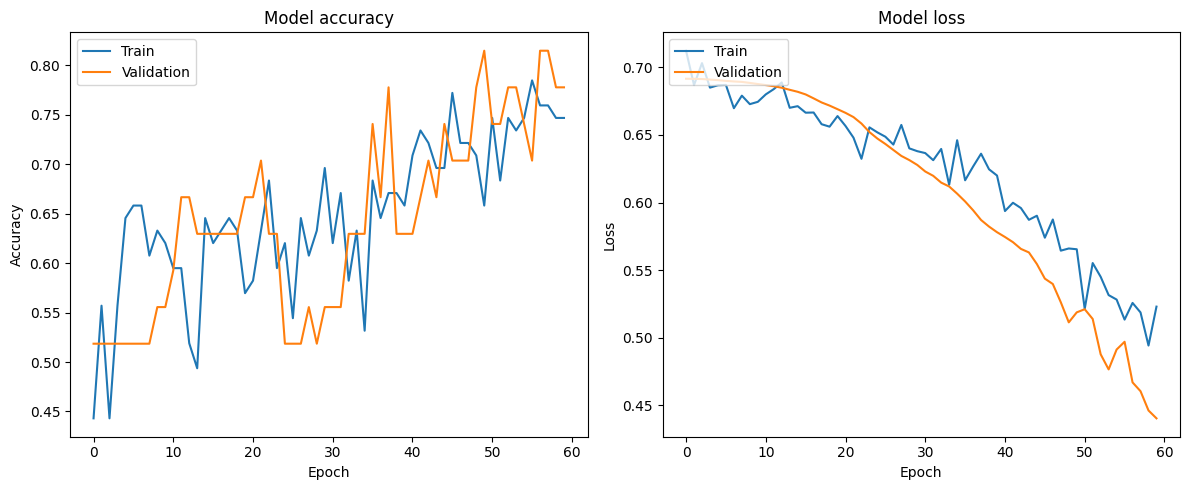

Training history plotted.


In [18]:
import matplotlib.pyplot as plt

# Plot training history (accuracy and loss)
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

print("Training history plotted.")

In [19]:
print('テストデータでの予測を開始します...')

# テストデータで予測を行う
y_pred_probs = model.predict(X_test)

# 確率から予測クラスを取得 (for sigmoid output, 0.5 is the threshold)
y_pred = (y_pred_probs > 0.5).astype(int).flatten() # Flatten for 1D labels

# クラス名に変換
actual_labels = [class_labels[label] for label in y_test]
predicted_labels = [class_labels[label] for label in y_pred]

# 結果を表示
import pandas as pd
results_df = pd.DataFrame({
    'Actual Label': actual_labels,
    'Predicted Label': predicted_labels
})

print('予測結果:')
display(results_df.head(10))

テストデータでの予測を開始します...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
予測結果:


,Actual Label,Predicted Label
0,Other,Other
1,Other,Other
2,Other,RegroupGoA_SlowGoA
3,RegroupGoA_SlowGoA,Other
4,RegroupGoA_SlowGoA,RegroupGoA_SlowGoA
5,RegroupGoA_SlowGoA,RegroupGoA_SlowGoA
6,Other,Other
7,RegroupGoA_SlowGoA,RegroupGoA_SlowGoA
8,Other,Other
9,Other,RegroupGoA_SlowGoA


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12505 (\N{KATAKANA LETTER BE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

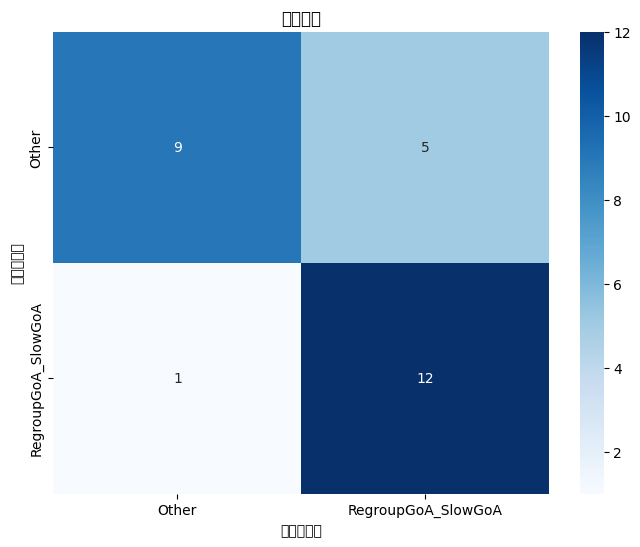


分類レポート:
                    precision    recall  f1-score   support

             Other       0.90      0.64      0.75        14
RegroupGoA_SlowGoA       0.71      0.92      0.80        13

          accuracy                           0.78        27
         macro avg       0.80      0.78      0.78        27
      weighted avg       0.81      0.78      0.77        27



In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # Import numpy for np.arange

# 混同行列を計算
cm = confusion_matrix(y_test, y_pred)

# 混同行列をヒートマップで表示
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('予測ラベル')
plt.ylabel('真のラベル')
plt.title('混同行列')
plt.show()

# 分類レポートを表示
print('\n分類レポート:')
# Fix: Explicitly pass all possible labels to classification_report
print(classification_report(y_test, y_pred, labels=np.arange(num_classes), target_names=class_labels))
